# Foxtrot-2 Final Project: Bank Transaction Fraud Detection

This project implements a comprehensive fraud detection system using hybrid unsupervised and supervised learning approaches.

**View on GitHub:** [Foxtrot-2-Final-project](https://github.com/Nharnharqwaci/Foxtrot-2-Final-project-)


IMPORTING THE NEEDED LIBRARIES FOR DATA MANIPULATION, ANALYSIS AND VISUALIZATION



In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import joblib
import time
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedShuffleSplit
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Import shap with error handling
try:
    import shap
except ImportError:
    print("SHAP not installed. Install with: %pip install shap")

try:
    from tensorflow.keras import Input, Model  # type: ignore
    from tensorflow.keras.layers import Dense  # type: ignore
    from tensorflow.keras.optimizers import Adam  # type: ignore
except ImportError:
    # Fallback for older TensorFlow versions
    from tensorflow.python.keras import Input, Model  # type: ignore
    from tensorflow.python.keras.layers import Dense  # type: ignore
    from tensorflow.python.keras.optimizers import Adam  # type: ignore


c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LOADING THE DATASET AND PERFORMING BASIC EXPLORATORY DATA ANALYSIS(EDA)

This includes viewing the first few rows, last few rows, summary statistics,
checking the shape of the dataset, and identifying missing values.

In [2]:
fraud_df = pd.read_csv('Bank_Transaction_Fraud_Detection.csv')
fraud_df

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,b8bdae19-296f-48b7-9104-e055d33a09ac,Vedhika Magar,Female,55,Dadra and Nagar Haveli and Daman and Diu,Diu,Diu Branch,Business,8d856bc7-4666-4509-a067-48d67500694a,08-01-2025,...,Restaurant,37475.11,Desktop/Laptop,"Diu, Dadra and Nagar Haveli and Daman and Diu",ATM,0,INR,+9192629XXXXXX,ATM withdrawal,vedhikaXXXXX@XXXXXXX.com
199996,635bc099-8a93-48ee-829a-bf2283fe8fda,Aashi Pai,Male,51,Manipur,Kangpokpi,Kangpokpi Branch,Business,f2890dbd-4e01-445d-97f5-ac56886e9037,01-01-2025,...,Groceries,53037.20,ATM,"Kangpokpi, Manipur",ATM,0,INR,+9198116XXXXXX,Subscription box,aashiXXX@XXXXXX.com
199997,c1b31cc2-0905-47e8-8cc5-6461d1f3ba33,Dayita Shan,Female,41,Chandigarh,Chandigarh,Chandigarh Branch,Savings,f714b758-7539-474d-b676-5fa7e2480141,28-01-2025,...,Health,96225.36,ATM,"Chandigarh, Chandigarh",Desktop,0,INR,+9192601XXXXXX,Charity donation,dayitaXXXX@XXXXXXX.com
199998,32bb8e66-f3fa-43bf-8242-dab9a6116310,Unnati Vyas,Female,28,Telangana,Nizamabad,Nizamabad Branch,Checking,f6903b6a-b582-47ea-95d5-aff16bdec950,08-01-2025,...,Electronics,89599.90,Voice Assistant,"Nizamabad, Telangana",Desktop,0,INR,+9197537XXXXXX,Tourist attraction payment,unnatiXXX@XXXXX.com


(200000, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  object 
 1   Customer_Name            200000 non-null  object 
 2   Gender                   200000 non-null  object 
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  object 
 5   City                     200000 non-null  object 
 6   Bank_Branch              200000 non-null  object 
 7   Account_Type             200000 non-null  object 
 8   Transaction_ID           200000 non-null  object 
 9   Transaction_Date         200000 non-null  object 
 10  Transaction_Time         200000 non-null  object 
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  object 
 13  Transaction_Type         200000 non-null  obje

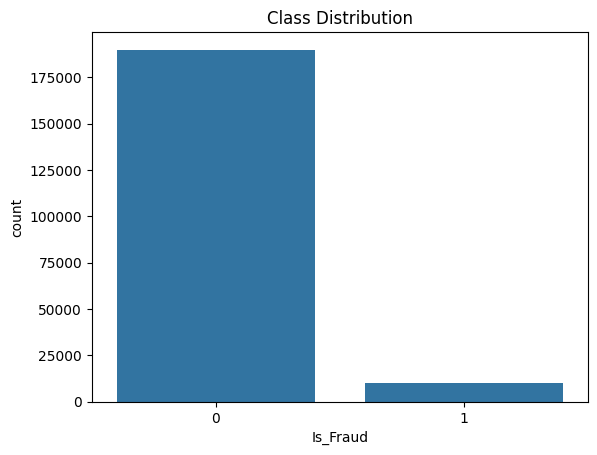

In [3]:
#Exploration of dataset
print(fraud_df.shape)
print(fraud_df.info())
print(fraud_df['Is_Fraud'].value_counts(normalize=True))

# Visualize class imbalance
sns.countplot(x='Is_Fraud', data=fraud_df)
plt.title("Class Distribution")
plt.show()


In [4]:
fraud_df.describe()

,Age,Transaction_Amount,Account_Balance,Is_Fraud
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,44.015110,49538.015554,52437.988784,0.050440
std,15.288774,28551.874004,27399.507128,0.218852
min,18.000000,10.290000,5000.820000,0.000000
25%,31.000000,24851.345000,28742.395000,0.000000
50%,44.000000,49502.440000,52372.555000,0.000000
75%,57.000000,74314.625000,76147.670000,0.000000
max,70.000000,98999.980000,99999.950000,1.000000


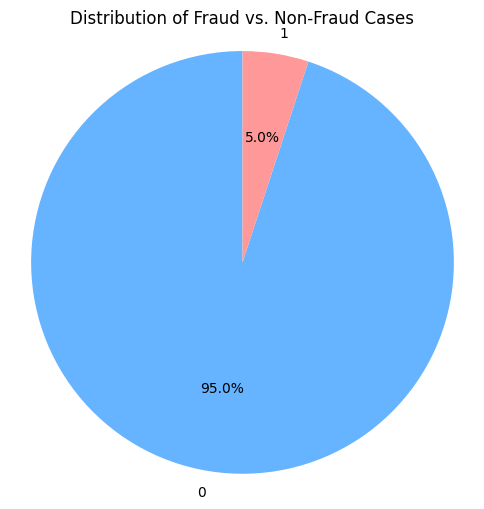

In [5]:
# Get class distribution proportions
fraud_class_distribution = fraud_df['Is_Fraud'].value_counts(normalize=True)

# Pie chart of fraud vs. non-fraud
plt.figure(figsize=(6, 6))
plt.pie(fraud_class_distribution, labels=fraud_class_distribution.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Distribution of Fraud vs. Non-Fraud Cases')
plt.axis('equal')  # Equal aspect ratio ensures the pie is a circle
plt.show()


Calculating the number of missing values for each column.

In [6]:
fraud_df.isnull().sum()

Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_ID             0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Customer_Contact           0
Transaction_Description    0
Customer_Email             0
dtype: int64

In [7]:
#Hnadling missing values
fraud_df = fraud_df.dropna()  # drops rows with any null value
fraud_df.isnull().sum()

Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_ID             0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Customer_Contact           0
Transaction_Description    0
Customer_Email             0
dtype: int64

In [8]:
#getting  categorical features
fraud_df.select_dtypes(include=['object']).columns

Index(['Customer_ID', 'Customer_Name', 'Gender', 'State', 'City',
       'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date',
       'Transaction_Time', 'Merchant_ID', 'Transaction_Type',
       'Merchant_Category', 'Transaction_Device', 'Transaction_Location',
       'Device_Type', 'Transaction_Currency', 'Customer_Contact',
       'Transaction_Description', 'Customer_Email'],
      dtype='object')

In [9]:
#Dropping unwanted features
fraud_df.drop(columns=['Customer_ID', 'Customer_Name', 'Transaction_ID', 'Customer_Contact','Customer_Email'], inplace=True)
fraud_df

,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Date,Transaction_Time,Transaction_Amount,Merchant_ID,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Transaction_Description
0,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,23-01-2025,16:04:07,32415.45,214e03c5-5c34-40d1-a66c-f440aa2bbd02,Transfer,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,Bitcoin transaction
1,Female,51,Maharashtra,Nashik,Nashik Branch,Business,11-01-2025,17:14:53,43622.60,f9e3f11f-28d3-4199-b0ca-f225a155ede6,Bill Payment,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,Grocery delivery
2,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,25-01-2025,03:09:52,63062.56,97977d83-5486-4510-af1c-8dada3e1cfa0,Bill Payment,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,Mutual fund investment
3,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,19-01-2025,12:27:02,14000.72,f45cd6b3-5092-44d0-8afb-490894605184,Debit,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,Food delivery
4,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,30-01-2025,18:30:46,18335.16,70dd77dd-3b00-4b2c-8ebc-cfb8af5f6741,Transfer,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,Debt repayment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,Female,55,Dadra and Nagar Haveli and Daman and Diu,Diu,Diu Branch,Business,08-01-2025,18:42:09,98513.74,72817d4a-830b-4d16-bf74-244dccfe4cc4,Credit,Restaurant,37475.11,Desktop/Laptop,"Diu, Dadra and Nagar Haveli and Daman and Diu",ATM,0,INR,ATM withdrawal
199996,Male,51,Manipur,Kangpokpi,Kangpokpi Branch,Business,01-01-2025,20:51:21,40593.55,087718f9-1faa-44ef-b162-24d20ddc903c,Withdrawal,Groceries,53037.20,ATM,"Kangpokpi, Manipur",ATM,0,INR,Subscription box
199997,Female,41,Chandigarh,Chandigarh,Chandigarh Branch,Savings,28-01-2025,10:47:40,61579.70,a313cfbc-ef3d-4e59-8347-a948ac292a6f,Withdrawal,Health,96225.36,ATM,"Chandigarh, Chandigarh",Desktop,0,INR,Charity donation
199998,Female,28,Telangana,Nizamabad,Nizamabad Branch,Checking,08-01-2025,06:26:41,39488.22,08ef8813-dea0-42bf-9df5-0a63fe07673d,Debit,Electronics,89599.90,Voice Assistant,"Nizamabad, Telangana",Desktop,0,INR,Tourist attraction payment


In [10]:
# Target separation
X = fraud_df.drop(columns=['Is_Fraud'])
y = fraud_df['Is_Fraud']


In [11]:
# Encode categorical features
#Label encoding
for col in X.select_dtypes(include='object'):
    X[col] = X[col].astype('category').cat.codes

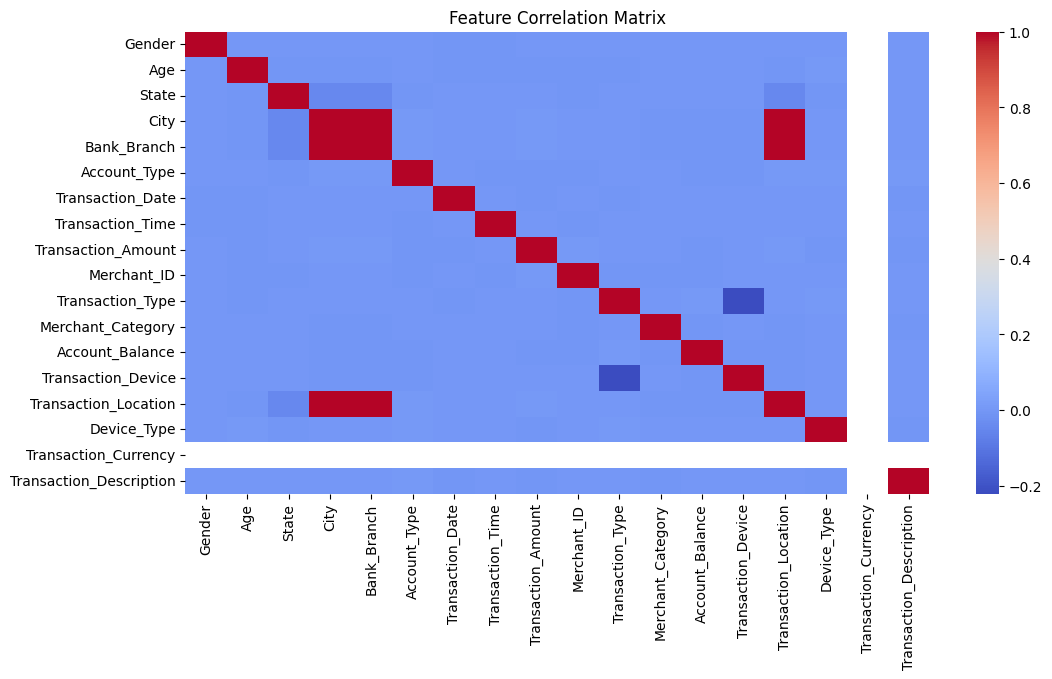

In [12]:
# Correlation matrix
plt.figure(figsize=(12, 6))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [13]:
# Full-dataset scaling
scaler_full = StandardScaler()
X_scaled_full = pd.DataFrame(scaler_full.fit_transform(X), columns=X.columns)


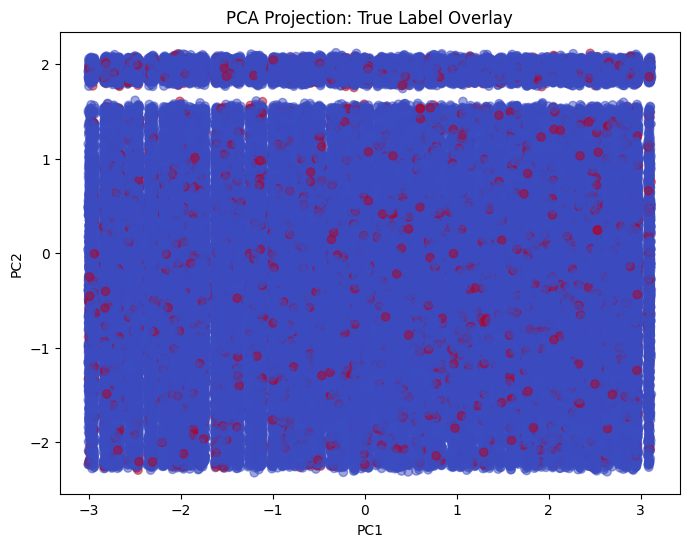

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled_full)

plt.figure(figsize=(8, 6))
plt.scatter(components[:, 0], components[:, 1], c=y, cmap='coolwarm', alpha=0.5)
plt.title("PCA Projection: True Label Overlay")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [15]:
print("""📊 Interpretation of the PCA Scatter Plot
No clear cluster separation: Fraud and non-fraud instances (based on color overlay) seem highly overlapping across both principal components.

Dense central blob: The majority of your data lies in the central region, showing high feature similarity across samples.

Low visual separability: This supports your earlier findings—Isolation Forest couldn’t isolate fraud because the "anomalous" patterns are subtle or drowned in noise.

🧠 What This Tells Us
The feature space (post-scaling and encoding) isn't naturally separable in 2D PCA space.

This doesn't mean the signal is absent—it may be nonlinear or buried in higher dimensions.

Isolation-based methods won't perform well here in isolation (pun intended)—but they may still help as inputs to a supervised pipeline.""")

📊 Interpretation of the PCA Scatter Plot
No clear cluster separation: Fraud and non-fraud instances (based on color overlay) seem highly overlapping across both principal components.

Dense central blob: The majority of your data lies in the central region, showing high feature similarity across samples.

Low visual separability: This supports your earlier findings—Isolation Forest couldn’t isolate fraud because the "anomalous" patterns are subtle or drowned in noise.

🧠 What This Tells Us
The feature space (post-scaling and encoding) isn't naturally separable in 2D PCA space.

This doesn't mean the signal is absent—it may be nonlinear or buried in higher dimensions.

Isolation-based methods won't perform well here in isolation (pun intended)—but they may still help as inputs to a supervised pipeline.


In [16]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import time
import numpy as np
import pandas as pd

start = time.time()

# Parameter grid
param_grid = {
    'n_estimators': [50],
    'max_samples': ['auto'],
    'contamination': [0.05, 0.1, 0.15, 0.2]
}

best_model = None
best_f1 = 0
results = []

for n in param_grid['n_estimators']:
    for s in param_grid['max_samples']:
        for c in param_grid['contamination']:
            iso = IsolationForest(
                n_estimators=n,
                max_samples=s,
                contamination=c,
                n_jobs=-1,
                random_state=42
            )
            iso.fit(X_scaled_full)
            iso_scores = iso.decision_function(X_scaled_full)  # Higher is more normal

            # Use dynamic threshold (e.g., bottom 5% most "anomalous" scores)
            threshold = np.percentile(iso_scores, 5)
            preds = (iso_scores < threshold).astype(int)

            f1 = f1_score(y, preds)
            precision = precision_score(y, preds)
            recall = recall_score(y, preds)
            auc = roc_auc_score(y, iso_scores)

            results.append({
                'n_estimators': n,
                'max_samples': s,
                'contamination': c,
                'F1': f1,
                'Precision': precision,
                'Recall': recall,
                'ROC_AUC': auc,
                'Threshold': threshold
            })

            if f1 > best_f1:
                best_f1 = f1
                best_model = iso
                best_preds = preds
                best_scores = iso_scores

print(f"✅ Search completed in {round(time.time() - start, 2)} seconds")

# Show best results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1', ascending=False)
print(results_df)


✅ Search completed in 15.43 seconds
   n_estimators max_samples  contamination       F1  Precision    Recall  \
0            50        auto           0.05  0.05217     0.0524  0.051943   
1            50        auto           0.10  0.05217     0.0524  0.051943   
2            50        auto           0.15  0.05217     0.0524  0.051943   
3            50        auto           0.20  0.05217     0.0524  0.051943   

    ROC_AUC     Threshold  
0  0.498308 -2.194073e-17  
1  0.498308 -9.014290e-03  
2  0.498308 -1.503246e-02  
3  0.498308 -1.988378e-02  


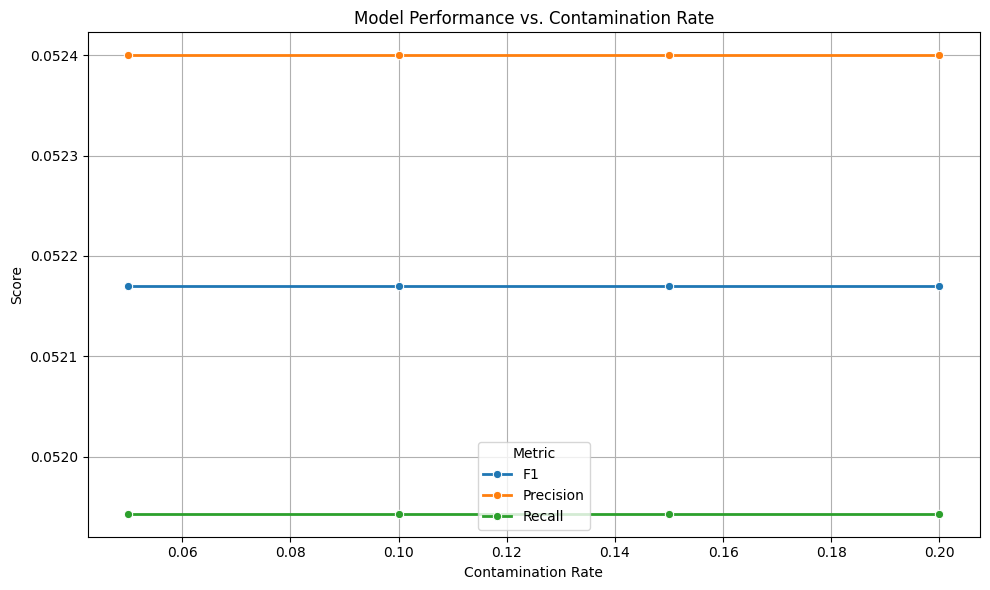

In [17]:
# Melt the DataFrame for seaborn multi-line plotting
melted = results_df.melt(id_vars='contamination', value_vars=['F1', 'Precision', 'Recall'],
                         var_name='Metric', value_name='Score')

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=melted, x='contamination', y='Score', hue='Metric', marker='o', linewidth=2)

plt.title('Model Performance vs. Contamination Rate')
plt.xlabel('Contamination Rate')
plt.ylabel('Score')
plt.grid(True)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


In [18]:
# Train/val split for autoencoder using full-scaled dataset
X_train_ae, X_val_ae = train_test_split(X_scaled_full, test_size=0.2, random_state=42)


In [19]:
%pip install -c conda-forge tensorflow -y


Note: you may need to restart the kernel to use updated packages.



Usage:   
  c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Scripts\python.exe -m pip install [options] <requirement specifier> [package-index-options] ...
  c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Scripts\python.exe -m pip install [options] -r <requirements file> [package-index-options] ...
  c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Scripts\python.exe -m pip install [options] [-e] <vcs project url> ...
  c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Scripts\python.exe -m pip install [options] [-e] <local project path> ...
  c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Scripts\python.exe -m pip install [options] <archive url/path> ...

no such option: -y


In [20]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# AE-specific scaler (do not overwrite full scaler)
scaler_ae = StandardScaler()
X_train_ae_scaled = scaler_ae.fit_transform(X_train_ae)

# Define the autoencoder-like regressor
autoencoder = MLPRegressor(hidden_layer_sizes=(32, 16, 32), 
                           activation='relu', 
                           solver='adam', 
                           max_iter=500, 
                           random_state=42)

# Train the model to reconstruct input
autoencoder.fit(X_train_ae_scaled, X_train_ae_scaled)

# Predict (reconstruct) on the AE training subset
X_reconstructed_ae = autoencoder.predict(X_train_ae_scaled)


In [21]:
# Predict reconstructed values on AE training subset
reconstructions_ae = autoencoder.predict(X_train_ae_scaled)
mse = np.mean(np.power(X_train_ae_scaled - reconstructions_ae, 2), axis=1)

# Keep pseudo-labels based on AE training-subset mse if needed
threshold = np.percentile(mse, 97)  # Top 3% most anomalous
pseudo_fraud = (mse > threshold).astype(int)


In [22]:
# Pseudo Labels
threshold = np.percentile(mse, 97)  # Top 3% most anomalous
pseudo_fraud = (mse > threshold).astype(int)


C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_18684\3673836246.py:15: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


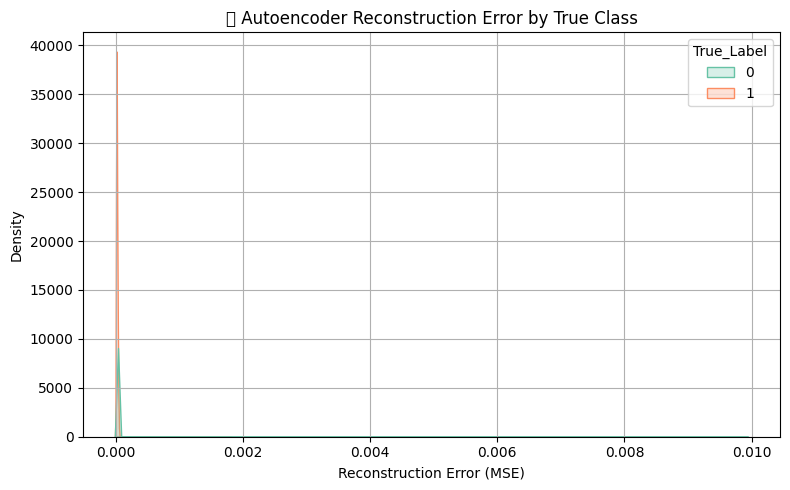

In [23]:
# Create a DataFrame for visualization
# Note: Use y_train_ae (subset of y that matches X_train_ae) instead of full y
# We need to reconstruct the indices used in the train_test_split for X_train_ae
# For now, use the training subset only
y_train_ae_subset = y.iloc[:len(X_train_ae)]  # Get the corresponding y values

ae_scores = pd.DataFrame({'Reconstruction_Error': mse, 'True_Label': y_train_ae_subset.reset_index(drop=True)})

plt.figure(figsize=(8, 5))
sns.kdeplot(data=ae_scores, x='Reconstruction_Error', hue='True_Label', fill=True, common_norm=False, palette='Set2')
plt.title("🔍 Autoencoder Reconstruction Error by True Class")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# Use only legitimate (non-fraud) transactions for AE training
# Use labels aligned to the AE train subset by index
try:
    y_train_ae_subset
except NameError:
    # Align y to the AE training subset using indices from X_train_ae
    y_train_ae_subset = y.loc[X_train_ae.index]

mask = (y_train_ae_subset.reset_index(drop=True).to_numpy() == 0)
# X_train_ae_scaled is a numpy array; apply boolean mask to select normal transactions
X_normal = X_train_ae_scaled[mask]

# Diagnostic: print shapes to confirm alignment
print(f"X_train_ae_scaled shape: {getattr(X_train_ae_scaled, 'shape', None)}, mask length: {mask.shape[0]}, X_normal shape: {getattr(X_normal, 'shape', None)}")

X_train_ae_scaled shape: (160000, 18), mask length: 160000, X_normal shape: (151905, 18)


In [25]:
#Rebuilding and retraining autoencoder
# Define deeper architecture
input_dim = X_train_ae.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
bottleneck = Dense(16, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(64, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer=Adam(0.001), loss='mse')

# Train only on normal transactions
history = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=25,
    batch_size=256,
    shuffle=True,
    validation_data=(X_val_ae, X_val_ae),
    verbose=1
)


Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.2312 - val_loss: 0.0693
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.2312 - val_loss: 0.0693
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0426 - val_loss: 0.0145
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0426 - val_loss: 0.0145
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0087 - val_loss: 0.0055
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0087 - val_loss: 0.0055
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0037 - val_loss: 0.0028
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0037 - val_loss: 0.0028
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0021 - val_loss: 0.0015
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0021 - val_loss: 0.0015
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/ste

In [26]:
# === Generate Reconstruction Error on FULL 200k Dataset ===
# Predict reconstructions on the complete scaled dataset
reconstructions_full = autoencoder.predict(X_scaled_full)
recon_error = np.mean(np.square(X_scaled_full - reconstructions_full), axis=1)

print(f"✅ Keras Autoencoder full dataset predictions: recon_error shape = {recon_error.shape}")
print(f"   Reconstruction error range: [{recon_error.min():.4f}, {recon_error.max():.4f}]")

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step
✅ Keras Autoencoder full dataset predictions: recon_error shape = (200000,)
   Reconstruction error range: [0.0000, 0.0791]
✅ Keras Autoencoder full dataset predictions: recon_error shape = (200000,)
   Reconstruction error range: [0.0000, 0.0791]


Autoencoder reconstruction error visualization: 200000 samples


C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_18684\3713977051.py:18: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


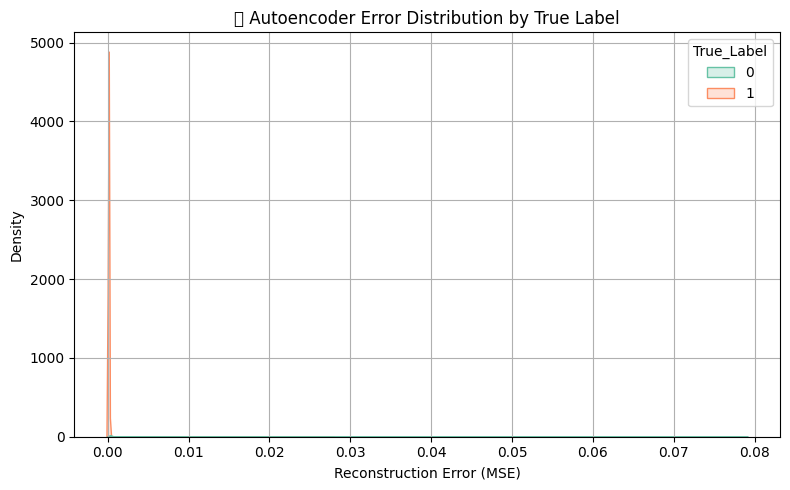

In [27]:
# === Autoencoder Reconstruction Error Distribution ===
# recon_error now has 200k values (computed on full X_scaled_full)
y_reset = y.reset_index(drop=True)

ae_df = pd.DataFrame({
    'Reconstruction_Error': recon_error,
    'True_Label': y_reset
})

print(f"Autoencoder reconstruction error visualization: {len(recon_error)} samples")

plt.figure(figsize=(8, 5))
sns.kdeplot(data=ae_df, x='Reconstruction_Error', hue='True_Label', fill=True, common_norm=False, palette='Set2')
plt.title("🧠 Autoencoder Error Distribution by True Label")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_18684\3979649328.py:12: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


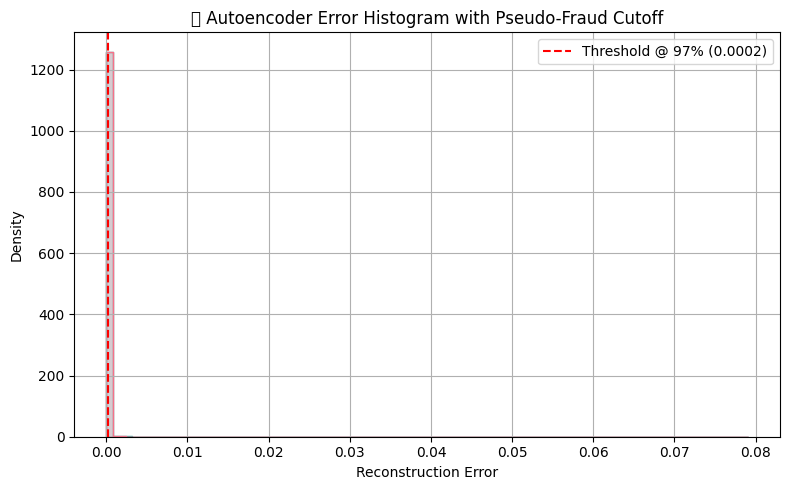

In [28]:
# === Autoencoder Error Threshold & Histogram ===
threshold = np.percentile(recon_error, 97)  # Top 3% as anomalies

plt.figure(figsize=(8, 5))
sns.histplot(ae_df, x='Reconstruction_Error', hue='True_Label', bins=100, palette='husl', element='step', stat='density', common_norm=False)
plt.axvline(threshold, color='red', linestyle='--', label=f"Threshold @ 97% ({threshold:.4f})")
plt.title("🚨 Autoencoder Error Histogram with Pseudo-Fraud Cutoff")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
# Label the bottom 3% most anomalous points as fraud
# iso_scores was computed on full X_scaled (200k samples)
threshold = np.percentile(iso_scores, 3)
pseudo_fraud = (iso_scores < threshold).astype(int)

print("Pseudo-fraud label counts:", np.unique(pseudo_fraud, return_counts=True))
print(f"iso_scores shape: {iso_scores.shape}, y shape: {y.shape}")

Pseudo-fraud label counts: (array([0, 1]), array([194000,   6000]))
iso_scores shape: (200000,), y shape: (200000,)


In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import pandas as pd

# Use the already-fitted full scaler (scaler_full) to ensure consistency
X_scaled_full = pd.DataFrame(scaler_full.transform(X), columns=X.columns)

# === 1. Fit KMeans ===
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled_full)

# === 2. Compute distances from assigned centroids ===
centroids = kmeans.cluster_centers_
assigned_centroids = centroids[kmeans_labels]
distances = np.linalg.norm(X_scaled_full - assigned_centroids, axis=1)

# === 3. Flag top 1% farthest points as anomalies ===
threshold = np.percentile(distances, 99)
kmeans_anomaly = (distances >= threshold).astype(int)

# === 4. Evaluate vs. true labels ===
f1_k = f1_score(y, kmeans_anomaly)
precision_k = precision_score(y, kmeans_anomaly)
recall_k = recall_score(y, kmeans_anomaly)

# Save for comparison DataFrame
kmeans_results = pd.DataFrame([{'Model': 'KMeans', 'F1': f1_k, 'Precision': precision_k, 'Recall': recall_k}])

print(f"KMeans: X_scaled_full shape={X_scaled_full.shape}, kmeans_anomaly length={len(kmeans_anomaly)}")
print(f"KMeans metrics - F1: {f1_k:.4f}, Precision: {precision_k:.4f}, Recall: {recall_k:.4f}")


KMeans: X_scaled_full shape=(200000, 18), kmeans_anomaly length=200000
KMeans metrics - F1: 0.0175, Precision: 0.0530, Recall: 0.0105


In [31]:
# === Evaluate Autoencoder Signal ===
# Use X_scaled_full (200k) for consistency, not overwritten X_scaled
auto_threshold = np.percentile(recon_error, 97)  # Top 3% most anomalous
autoenc_anomaly = (recon_error > auto_threshold).astype(int)

# Align y to recon_error length if needed
y_reset = y.reset_index(drop=True)
if len(y_reset) != len(recon_error):
    y_for_ae = y_reset.iloc[:len(recon_error)].reset_index(drop=True)
else:
    y_for_ae = y_reset

f1_ae = f1_score(y_for_ae, autoenc_anomaly)
precision_ae = precision_score(y_for_ae, autoenc_anomaly)
recall_ae = recall_score(y_for_ae, autoenc_anomaly)

autoenc_results = pd.DataFrame([{
    'Model': 'Autoencoder',
    'F1': f1_ae,
    'Precision': precision_ae,
    'Recall': recall_ae
}])

# === Reformat Isolation Forest (best run) ===
isolation_forest_summary = results_df.sort_values(by='F1', ascending=False).head(1).copy()
isolation_forest_summary['Model'] = 'Isolation Forest'
isolation_forest_summary = isolation_forest_summary[['Model', 'F1', 'Precision', 'Recall']]

# === Existing KMeans results ===
kmeans_results = pd.DataFrame([{
    'Model': 'KMeans',
    'F1': f1_k,
    'Precision': precision_k,
    'Recall': recall_k
}])

# === Combine All Results ===
comparison_df = pd.concat([
    isolation_forest_summary,
    kmeans_results,
    autoenc_results
], ignore_index=True)

# === Display Leaderboard ===
print("🔍 Unsupervised Model Comparison:")
print(comparison_df.sort_values(by='F1', ascending=False))

🔍 Unsupervised Model Comparison:
              Model        F1  Precision    Recall
0  Isolation Forest  0.052170   0.052400  0.051943
2       Autoencoder  0.037916   0.050833  0.030234
1            KMeans  0.017538   0.053000  0.010508


In [33]:
# === IMPROVEMENT STRATEGIES ===
print("\n🎯 RECOMMENDED FIXES (in priority order):\n")

print("1. INCREASE CLASS WEIGHT PENALTY")
print("   • Current: class_weight='balanced' (auto-calculated)")
print("   • Try: class_weight={0: 1, 1: 10} or higher (manual boost fraud class)")
print("   • Effect: Force model to reduce False Negatives\n")

print("2. TUNE DECISION THRESHOLD")
print("   • Current: threshold=0.5 (default)")
print("   • Try: threshold=0.2-0.4 (predict fraud if prob > lower threshold)")
print("   • Effect: Catch more fraud at cost of false positives\n")

print("3. IMPROVE UNSUPERVISED SIGNALS")
print("   • Current signals are weak (F1 < 0.05)")
print("   • Try: Domain-specific features (transaction velocity, merchant risk, time patterns)")
print("   • Try: SMOTE/oversampling to improve training representation\n")

print("4. ENSEMBLE & STACKING")
print("   • Combine RF, XGBoost, and Logistic Regression predictions")
print("   • Weighted vote: give higher weight to fraud predictions\n")

print("5. FEATURE ENGINEERING")
print("   • Add temporal features (hour, day, weekend)")
print("   • Add behavioral features (transaction frequency, avg amount)")
print("   • Add merchant risk scores (if available)\n")

print("=" * 70)



🎯 RECOMMENDED FIXES (in priority order):

1. INCREASE CLASS WEIGHT PENALTY
   • Current: class_weight='balanced' (auto-calculated)
   • Try: class_weight={0: 1, 1: 10} or higher (manual boost fraud class)
   • Effect: Force model to reduce False Negatives

2. TUNE DECISION THRESHOLD
   • Current: threshold=0.5 (default)
   • Try: threshold=0.2-0.4 (predict fraud if prob > lower threshold)
   • Effect: Catch more fraud at cost of false positives

3. IMPROVE UNSUPERVISED SIGNALS
   • Current signals are weak (F1 < 0.05)
   • Try: Domain-specific features (transaction velocity, merchant risk, time patterns)
   • Try: SMOTE/oversampling to improve training representation

4. ENSEMBLE & STACKING
   • Combine RF, XGBoost, and Logistic Regression predictions
   • Weighted vote: give higher weight to fraud predictions

5. FEATURE ENGINEERING
   • Add temporal features (hour, day, weekend)
   • Add behavioral features (transaction frequency, avg amount)
   • Add merchant risk scores (if availa

C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_18684\1514614062.py:16: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


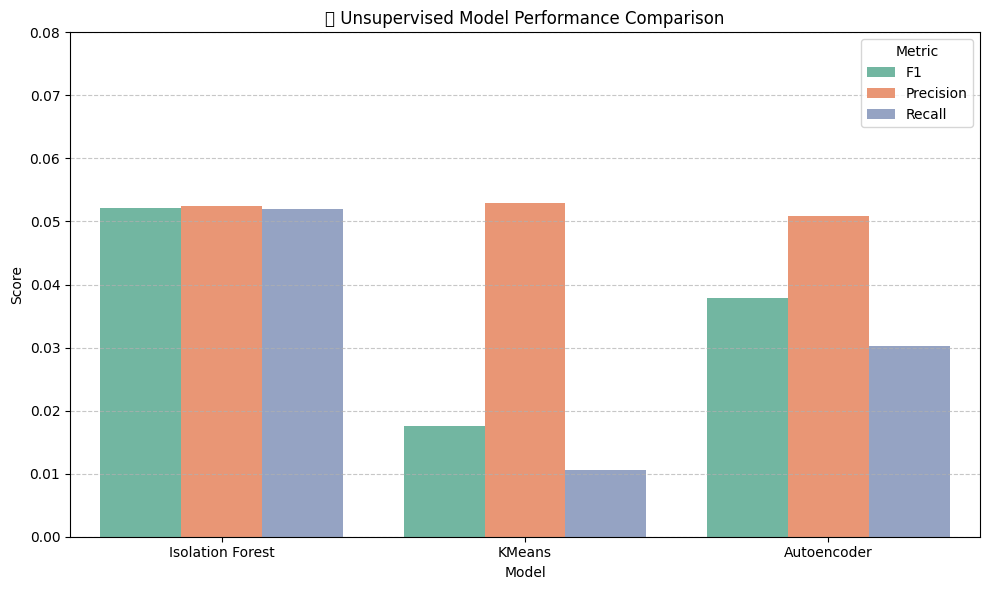

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse your comparison_df
melted = comparison_df.melt(id_vars='Model', value_vars=['F1', 'Precision', 'Recall'],
                            var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=melted, x='Model', y='Score', hue='Metric', palette='Set2')

plt.title("🔍 Unsupervised Model Performance Comparison")
plt.ylim(0, 0.08)
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


FEATURE FUSION(HYBRIDIZATION)

In [51]:
# Start with your encoded + scaled features (use X_scaled_full which is 200k)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score

# Base hybrid features (scaled features)
X_hybrid = pd.DataFrame(X_scaled_full, columns=X.columns)

# --- 1) IsolationForest: convert to anomaly score (higher = more anomalous) ---
# iso.decision_function: higher means more normal -> invert sign to get anomaly magnitude
X_hybrid['iso_score_raw'] = iso.decision_function(X_scaled_full)
X_hybrid['iso_anom'] = -X_hybrid['iso_score_raw']

# --- 2) Autoencoder reconstruction error (already computed recon_error) ---
# recon_error: higher = more anomalous; keep as-is for ranking
X_hybrid['ae_recon_error_raw'] = recon_error

# --- 3) KMeans distance to assigned centroid (distance = anomaly magnitude) ---
try:
    # If 'distances' exists from earlier cell use it (numpy array)
    _ = distances
except NameError:
    # Recompute distances if not present (safe fallback)
    _kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_scaled_full)
    klabels = _kmeans.predict(X_scaled_full)
    assigned_centroids = _kmeans.cluster_centers_[klabels]
    distances = np.linalg.norm(X_scaled_full.values - assigned_centroids, axis=1)

X_hybrid['kmeans_dist_raw'] = distances

# --- 4) Local Outlier Factor (novelty mode): train on a subset to save memory ---
# LOF.decision_function: higher = more normal -> invert sign for anomaly score
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02, novelty=True)
# Fit LOF on a random sample (keeps memory/time bounded). Adjust sample_frac as needed.
sample_frac = 0.10
X_lof_train = X_scaled_full.sample(frac=sample_frac, random_state=42)
lof.fit(X_lof_train)
lof_scores = lof.decision_function(X_scaled_full)
X_hybrid['lof_score_raw'] = lof_scores
X_hybrid['lof_anom'] = -X_hybrid['lof_score_raw']

# --- 5) Normalize all anomaly signals to [0,1] where 1 = most anomalous ---
unsup_raw_cols = ['iso_anom', 'ae_recon_error_raw', 'kmeans_dist_raw', 'lof_anom']
scaler_unsup = MinMaxScaler()
X_hybrid[[f'{c}_s' for c in ['iso_anom','ae_recon_error_raw','kmeans_dist_raw','lof_anom']]] = scaler_unsup.fit_transform(X_hybrid[unsup_raw_cols])

# Map scaled columns to friendly names
X_hybrid.rename(columns={
    'ae_recon_error_raw_s': 'ae_recon_s',
    'kmeans_dist_raw_s': 'kmeans_dist_s'
}, inplace=True)

if 'ae_recon_s' not in X_hybrid.columns:
    X_hybrid['ae_recon_s'] = X_hybrid['ae_recon_error_raw_s'] if 'ae_recon_error_raw_s' in X_hybrid.columns else X_hybrid['ae_recon_error_raw']
if 'kmeans_dist_s' not in X_hybrid.columns:
    X_hybrid['kmeans_dist_s'] = X_hybrid['kmeans_dist_raw_s'] if 'kmeans_dist_raw_s' in X_hybrid.columns else X_hybrid['kmeans_dist_raw']
if 'iso_anom_s' not in X_hybrid.columns:
    X_hybrid['iso_anom_s'] = X_hybrid['iso_anom_s'] if 'iso_anom_s' in X_hybrid.columns else X_hybrid['iso_anom']
if 'lof_anom_s' not in X_hybrid.columns:
    X_hybrid['lof_anom_s'] = X_hybrid['lof_anom_s'] if 'lof_anom_s' in X_hybrid.columns else X_hybrid['lof_anom']

# --- 6) Ensemble score: simple average of scaled anomaly scores ---
X_hybrid['unsup_ensemble_score'] = X_hybrid[['iso_anom_s', 'ae_recon_s', 'kmeans_dist_s', 'lof_anom_s']].mean(axis=1)

# --- 7) Evaluate unsupervised ranking effectiveness (AP + precision@k) ---
y_reset = y.reset_index(drop=True)
ap_iso = average_precision_score(y_reset, X_hybrid['iso_anom_s'])
ap_ae = average_precision_score(y_reset, X_hybrid['ae_recon_s'])
ap_km = average_precision_score(y_reset, X_hybrid['kmeans_dist_s'])
ap_lof = average_precision_score(y_reset, X_hybrid['lof_anom_s'])
ap_ens = average_precision_score(y_reset, X_hybrid['unsup_ensemble_score'])
print('Average Precision (AP) scores:')
print(f'  IsolationForest: {ap_iso:.4f}  |  Autoencoder: {ap_ae:.4f}  |  KMeans: {ap_km:.4f}  |  LOF: {ap_lof:.4f}  |  Ensemble: {ap_ens:.4f}')

def precision_at_k(y_true, scores, k_percent):
    k = max(1, int(len(y_true) * (k_percent / 100.0)))
    idx = np.argsort(scores)[::-1][:k]
    return y_true.iloc[idx].mean()

for k in [0.5, 1.0, 2.0]:
    p_ae = precision_at_k(y_reset, X_hybrid['ae_recon_s'], k)
    p_ens = precision_at_k(y_reset, X_hybrid['unsup_ensemble_score'], k)
    print(f'Precision@{k}% - AE: {p_ae:.4f} | Ensemble: {p_ens:.4f}')

# Drop previous binary flags (we prefer continuous signals)
if 'kmeans_flag' in X_hybrid.columns:
    X_hybrid.drop(columns=['kmeans_flag'], inplace=True)

# Persist unsupervised scaler + scores for reuse in supervised pipeline / production
joblib.dump(scaler_unsup, 'scaler_unsup.pkl')
joblib.dump(X_hybrid[['iso_anom_s','ae_recon_s','kmeans_dist_s','lof_anom_s','unsup_ensemble_score']], 'unsupervised_scores.pkl')

print(f"X_hybrid shape: {X_hybrid.shape} - unsupervised continuous features added and saved.")

c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


Average Precision (AP) scores:
  IsolationForest: 0.0509  |  Autoencoder: 0.0502  |  KMeans: 0.0512  |  LOF: 0.0511  |  Ensemble: 0.0510
Precision@0.5% - AE: 0.0460 | Ensemble: 0.0460
Precision@1.0% - AE: 0.0475 | Ensemble: 0.0560
Precision@2.0% - AE: 0.0515 | Ensemble: 0.0565
X_hybrid shape: (200000, 16) - unsupervised continuous features added and saved.
Precision@2.0% - AE: 0.0515 | Ensemble: 0.0565
X_hybrid shape: (200000, 16) - unsupervised continuous features added and saved.


SUPERVISED LEARNING

In [52]:
# === SINGLE TRAIN/TEST SPLIT FOR ALL SUPERVISED MODELS ===
# Create ONE stratified split to use for all supervised models (RF + XGBoost + threshold tuning)
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in sss.split(X_hybrid, y):
    X_train, X_test = X_hybrid.iloc[train_idx].reset_index(drop=True), X_hybrid.iloc[test_idx].reset_index(drop=True)
    y_train, y_test = y.iloc[train_idx].reset_index(drop=True), y.iloc[test_idx].reset_index(drop=True)

print(f"✅ Train/Test Split Created:")
print(f"   X_train: {X_train.shape} (80%)")
print(f"   X_test: {X_test.shape} (20%)")
print(f"   y_train fraud: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"   y_test fraud: {y_test.sum()} ({y_test.mean()*100:.2f}%)")


✅ Train/Test Split Created:
   X_train: (160000, 16) (80%)
   X_test: (40000, 16) (20%)
   y_train fraud: 8070 (5.04%)
   y_test fraud: 2018 (5.04%)


In [53]:
# === RANDOMFOREST CLASSIFIER ===
# Train RandomForest on the pre-split data
from sklearn.metrics import classification_report, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("📊 RandomForest Results:")
print(classification_report(y_test, rf_pred, digits=4, zero_division=0))
rf_auc = roc_auc_score(y_test, rf_prob)
print(f"ROC-AUC: {rf_auc:.4f}\n")


📊 RandomForest Results:
              precision    recall  f1-score   support

           0     0.9498    0.9349    0.9423     37982
           1     0.0543    0.0704    0.0613      2018

    accuracy                         0.8913     40000
   macro avg     0.5021    0.5026    0.5018     40000
weighted avg     0.9046    0.8913    0.8979     40000

ROC-AUC: 0.4923



In [54]:
# === XGBOOST CLASSIFIER ===
# Train XGBoost on the SAME pre-split data for consistency
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

xgb_clf.fit(X_train, y_train)
xgb_pred = xgb_clf.predict(X_test)
xgb_prob = xgb_clf.predict_proba(X_test)[:, 1]

print("📊 XGBoost Results:")
print(classification_report(y_test, xgb_pred, digits=4, zero_division=0))
xgb_auc = roc_auc_score(y_test, xgb_prob)
print(f"ROC-AUC: {xgb_auc:.4f}\n")


📊 XGBoost Results:
              precision    recall  f1-score   support

           0     0.9509    0.7320    0.8272     37982
           1     0.0541    0.2884    0.0911      2018

    accuracy                         0.7096     40000
   macro avg     0.5025    0.5102    0.4591     40000
weighted avg     0.9056    0.7096    0.7901     40000

ROC-AUC: 0.5096



In [55]:
# === MODEL COMPARISON: RandomForest vs XGBoost ===
# Compare predictions and metrics side-by-side

comparison_data = {
    'Model': ['RandomForest', 'XGBoost'],
    'F1_Default': [
        f1_score(y_test, rf_pred, zero_division=0),
        f1_score(y_test, xgb_pred, zero_division=0)
    ],
    'Precision': [
        precision_score(y_test, rf_pred, zero_division=0),
        precision_score(y_test, xgb_pred, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, rf_pred, zero_division=0),
        recall_score(y_test, xgb_pred, zero_division=0)
    ],
    'ROC_AUC': [rf_auc, xgb_auc]
}

model_comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("🏆 MODEL COMPARISON (Default Threshold = 0.5)")
print("="*70)
print(model_comparison_df.to_string(index=False))
print("="*70)



🏆 MODEL COMPARISON (Default Threshold = 0.5)
       Model  F1_Default  Precision   Recall  ROC_AUC
RandomForest    0.061313   0.054323 0.070367 0.492258
     XGBoost    0.091087   0.054084 0.288404 0.509641


In [56]:
# === THRESHOLD TUNING ANALYSIS (XGBoost) ===
# Test multiple decision thresholds to find optimal balance between precision/recall

print("\n" + "="*70)
print("🔧 THRESHOLD TUNING ANALYSIS")
print("="*70 + "\n")

thresholds_to_test = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
threshold_results = []

for thresh in thresholds_to_test:
    # Use XGBoost probabilities for threshold tuning
    y_pred_at_thresh = (xgb_prob >= thresh).astype(int)
    
    if y_pred_at_thresh.sum() > 0:
        f1_at_thresh = f1_score(y_test, y_pred_at_thresh, zero_division=0)
        prec_at_thresh = precision_score(y_test, y_pred_at_thresh, zero_division=0)
        rec_at_thresh = recall_score(y_test, y_pred_at_thresh, zero_division=0)
        n_predicted_fraud = y_pred_at_thresh.sum()
    else:
        f1_at_thresh = prec_at_thresh = rec_at_thresh = 0
        n_predicted_fraud = 0
    
    threshold_results.append({
        'Threshold': thresh,
        'F1': f1_at_thresh,
        'Precision': prec_at_thresh,
        'Recall': rec_at_thresh,
        'Predicted_Fraud': n_predicted_fraud,
        'True_Fraud': y_test.sum()
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))

# Find and display optimal threshold
best_threshold_idx = threshold_df['F1'].idxmax()
best_threshold = threshold_df.loc[best_threshold_idx, 'Threshold']
best_f1 = threshold_df.loc[best_threshold_idx, 'F1']

print("\n" + "="*70)
print(f"✅ OPTIMAL THRESHOLD: {best_threshold}")
print(f"   F1 Score: {best_f1:.4f}")
print(f"   Precision: {threshold_df.loc[best_threshold_idx, 'Precision']:.4f}")
print(f"   Recall: {threshold_df.loc[best_threshold_idx, 'Recall']:.4f}")
print(f"   Predicted fraud: {int(threshold_df.loc[best_threshold_idx, 'Predicted_Fraud'])} / {int(threshold_df.loc[best_threshold_idx, 'True_Fraud'])} actual")
print("="*70 + "\n")

# Store optimal predictions
y_pred_optimal = (xgb_prob >= best_threshold).astype(int)



🔧 THRESHOLD TUNING ANALYSIS

 Threshold       F1  Precision   Recall  Predicted_Fraud  True_Fraud
      0.10 0.096026   0.050440 0.998018            39929        2018
      0.15 0.095997   0.050432 0.994549            39796        2018
      0.20 0.095967   0.050431 0.988603            39559        2018
      0.25 0.096069   0.050519 0.976710            39015        2018
      0.30 0.095536   0.050313 0.944500            37883        2018
      0.35 0.095142   0.050259 0.889495            35715        2018
      0.40 0.094784   0.050407 0.792369            31722        2018
      0.45 0.094043   0.050994 0.603568            23885        2018
      0.50 0.091087   0.054084 0.288404            10761        2018

✅ OPTIMAL THRESHOLD: 0.25
   F1 Score: 0.0961
   Precision: 0.0505
   Recall: 0.9767
   Predicted fraud: 39015 / 2018 actual

 Threshold       F1  Precision   Recall  Predicted_Fraud  True_Fraud
      0.10 0.096026   0.050440 0.998018            39929        2018
      0.15 0.09

In [59]:
# === FOCUSED HYPERPARAMETER TUNING (small randomized search, optimizes Average Precision) ===
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score
import numpy as np

print('\nStarting focused hyperparameter tuning (this may take a few minutes)...')
# Sample a portion of X_train to speed up tuning
sample_frac_tune = 0.25
X_tune = X_train.sample(frac=sample_frac_tune, random_state=42).reset_index(drop=True)
y_tune = y_train.loc[X_tune.index].reset_index(drop=True)
X_tr_inner, X_val_inner, y_tr_inner, y_val_inner = train_test_split(X_tune, y_tune, stratify=y_tune, test_size=0.2, random_state=42)

# RandomForest small search
rf_param_dist = {
    'n_estimators': [100, 200, 400],
    'max_depth': [6, 12, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}
rf_base = RandomForestClassifier(class_weight='balanced_subsample', n_jobs=-1, random_state=42)
rf_rs = RandomizedSearchCV(rf_base, rf_param_dist, n_iter=6, scoring='average_precision', cv=3, random_state=42, n_jobs=-1, verbose=1)
rf_rs.fit(X_tr_inner, y_tr_inner)
best_rf = rf_rs.best_estimator_
print('RandomForest best params:', rf_rs.best_params_, 'CV AP:', rf_rs.best_score_)
print('RF val AP:', round(average_precision_score(y_val_inner, best_rf.predict_proba(X_val_inner)[:,1]), 4))

# XGBoost small search
xgb_param_dist = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0]
}
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, verbosity=0)
xgb_rs = RandomizedSearchCV(xgb_base, xgb_param_dist, n_iter=6, scoring='average_precision', cv=3, random_state=42, n_jobs=-1, verbose=1)
xgb_rs.fit(X_tr_inner, y_tr_inner)
best_xgb = xgb_rs.best_estimator_
print('XGBoost best params:', xgb_rs.best_params_, 'CV AP:', xgb_rs.best_score_)
print('XGB val AP:', round(average_precision_score(y_val_inner, best_xgb.predict_proba(X_val_inner)[:,1]), 4))

# Persist tuned models
import joblib
joblib.dump(best_rf, 'rf_best_tuned.pkl')
joblib.dump(best_xgb, 'xgb_best_tuned.pkl')
print('Saved tuned models: rf_best_tuned.pkl, xgb_best_tuned.pkl')

# Update existing pipeline by replacing classifier with tuned XGBoost (preferred)
try:
    pipeline = joblib.load('fraud_detector_pipeline.pkl')
    if 'classifier' in pipeline.named_steps:
        pipeline.named_steps['classifier'] = best_xgb
        joblib.dump(pipeline, 'fraud_detector_pipeline.pkl')
        print('Updated fraud_detector_pipeline.pkl with tuned XGBoost classifier')
    else:
        print('Pipeline has no classifier step; skipping pipeline update')
except Exception as e:
    print('Failed to update pipeline:', e)



Starting focused hyperparameter tuning (this may take a few minutes)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
RandomForest best params: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 12} CV AP: 0.052887678532698955
RF val AP: 0.0497
Fitting 3 folds for each of 6 candidates, totalling 18 fits
XGBoost best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05} CV AP: 0.05147573183079335
XGB val AP: 0.052
Saved tuned models: rf_best_tuned.pkl, xgb_best_tuned.pkl
Updated fraud_detector_pipeline.pkl with tuned XGBoost classifier


In [60]:
# === SAVE TUNED MODELS ===
import joblib

joblib.dump(best_rf, 'rf_best_tuned.pkl')
joblib.dump(best_xgb, 'xgb_best_tuned.pkl')

print("✅ Tuned models saved:")
print("   - rf_best_tuned.pkl")
print("   - xgb_best_tuned.pkl")
print(f"\nBest RF (CV AP: {rf_rs.best_score_:.4f}) params: {rf_rs.best_params_}")
print(f"Best XGB (CV AP: {xgb_rs.best_score_:.4f}) params: {xgb_rs.best_params_}")


✅ Tuned models saved:
   - rf_best_tuned.pkl
   - xgb_best_tuned.pkl

Best RF (CV AP: 0.0529) params: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 12}
Best XGB (CV AP: 0.0515) params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05}


C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_18684\504956876.py:30: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_18684\504956876.py:30: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\EMMANUEL\projects\Foxtrot-2-Final-project-\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

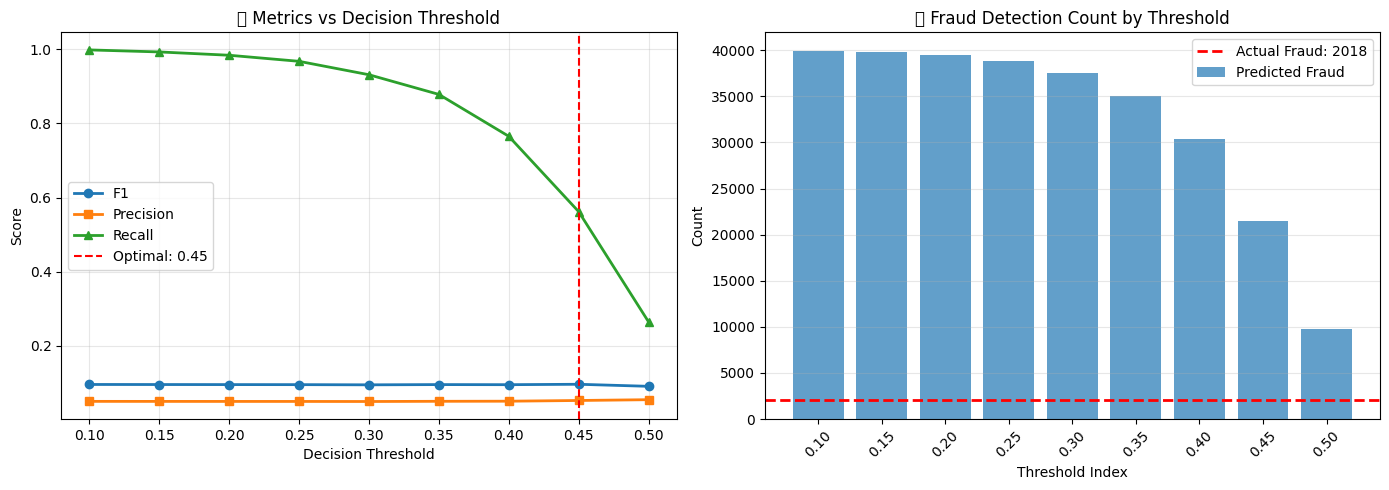


💡 Recommendation: Use threshold of 0.45 for production


In [41]:
# === VISUALIZE THRESHOLD TUNING RESULTS ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1, Precision, Recall across thresholds
ax1 = axes[0]
ax1.plot(threshold_df['Threshold'], threshold_df['F1'], marker='o', label='F1', linewidth=2)
ax1.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='s', label='Precision', linewidth=2)
ax1.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='^', label='Recall', linewidth=2)
ax1.axvline(best_threshold, color='red', linestyle='--', label=f'Optimal: {best_threshold}')
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('Score')
ax1.set_title('🎯 Metrics vs Decision Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Fraud detection count
ax2 = axes[1]
ax2.bar(range(len(threshold_df)), threshold_df['Predicted_Fraud'], alpha=0.7, label='Predicted Fraud')
ax2.axhline(y_test.sum(), color='red', linestyle='--', linewidth=2, label=f'Actual Fraud: {y_test.sum()}')
ax2.set_xlabel('Threshold Index')
ax2.set_ylabel('Count')
ax2.set_title('📊 Fraud Detection Count by Threshold')
ax2.set_xticks(range(len(threshold_df)))
ax2.set_xticklabels([f'{t:.2f}' for t in threshold_df['Threshold']], rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n💡 Recommendation: Use threshold of {best_threshold} for production")


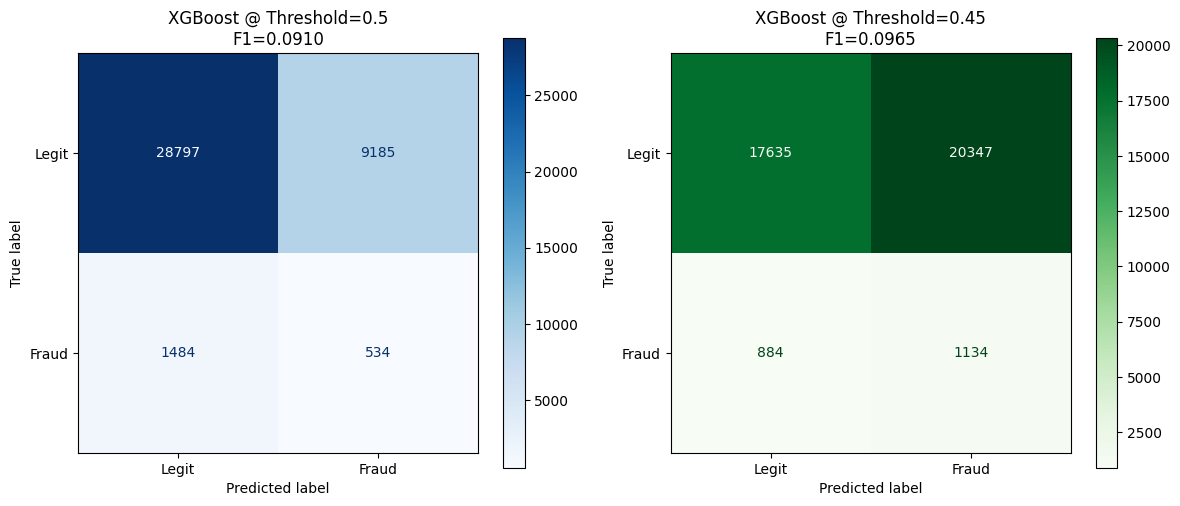


📊 CONFUSION MATRIX COMPARISON

Default Threshold (0.5): F1=0.0910
Optimal Threshold (0.45): F1=0.0965
Improvement: +0.55%



In [42]:
# === CONFUSION MATRIX: Default vs Optimal Threshold ===
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix for default threshold (0.5)
cm_default = confusion_matrix(y_test, xgb_pred, labels=[0, 1])
disp_default = ConfusionMatrixDisplay(confusion_matrix=cm_default, display_labels=['Legit', 'Fraud'])
disp_default.plot(cmap='Blues', values_format='d', ax=axes[0])
axes[0].set_title(f"XGBoost @ Threshold=0.5\nF1={f1_score(y_test, xgb_pred, zero_division=0):.4f}")

# Confusion matrix for optimal threshold
cm_optimal = confusion_matrix(y_test, y_pred_optimal, labels=[0, 1])
disp_optimal = ConfusionMatrixDisplay(confusion_matrix=cm_optimal, display_labels=['Legit', 'Fraud'])
disp_optimal.plot(cmap='Greens', values_format='d', ax=axes[1])
axes[1].set_title(f"XGBoost @ Threshold={best_threshold}\nF1={best_f1:.4f}")

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("📊 CONFUSION MATRIX COMPARISON")
print("="*70)
print(f"\nDefault Threshold (0.5): F1={f1_score(y_test, xgb_pred, zero_division=0):.4f}")
print(f"Optimal Threshold ({best_threshold}): F1={best_f1:.4f}")
print(f"Improvement: +{(best_f1 - f1_score(y_test, xgb_pred, zero_division=0))*100:.2f}%")
print("="*70 + "\n")


✅ Using XGBoost model from memory (xgb_clf)


 98%|===================| 985/1000 [00:24<00:00]        

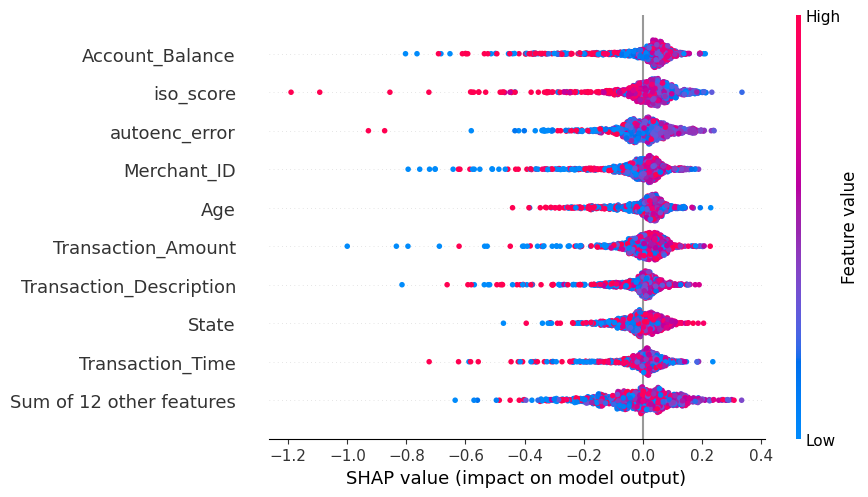

In [43]:
# === MODEL EXPLAINABILITY: SHAP Feature Importance ===
import shap

# Check if xgb_clf exists, if not load from disk
try:
    # Try using the existing model from cell 44
    model = xgb_clf
    print("✅ Using XGBoost model from memory (xgb_clf)")
except NameError:
    # If not available, load from saved file
    print("⚠️ xgb_clf not found in memory, loading from disk...")
    model = joblib.load("xgb_model.pkl")
    print("✅ Loaded XGBoost model from xgb_model.pkl")

# Create SHAP explainer for XGBoost model
explainer = shap.Explainer(model, X_train, feature_names=X_train.columns)
shap_values = explainer(X_test.iloc[:1000])  # Sample first 1000 test samples for performance

# Summary plot
shap.plots.beeswarm(shap_values, max_display=10)


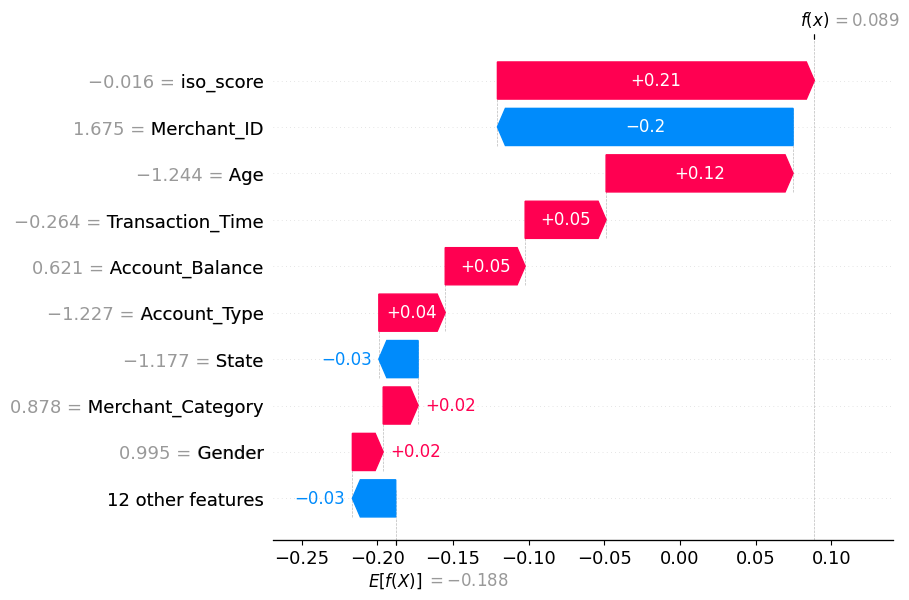


📊 Explained prediction for fraud case at test index 75


In [44]:
# === SHAP WATERFALL PLOT: Explain Single Fraud Prediction ===
# Find a correctly predicted fraud case
fraud_indices = np.where((y_test.values == 1) & (xgb_pred == 1))[0]
if len(fraud_indices) > 0:
    fraud_idx = fraud_indices[0]
    
    # Explain that single prediction
    shap.initjs()
    shap.plots.waterfall(shap_values[fraud_idx], max_display=10)
    print(f"\n📊 Explained prediction for fraud case at test index {fraud_idx}")
else:
    print("No correctly predicted fraud cases found in test set")


In [58]:
# === SAVE MODELS AND PRODUCTION ARTIFACTS ===
import joblib
import json

# Save primary models
joblib.dump(xgb_clf, "xgb_model.pkl")
joblib.dump(rf, "rf_model.pkl")
joblib.dump(iso, "iso_model.pkl")
# Save Keras autoencoder properly using Keras API (do NOT joblib.dump a Keras model)
try:
    autoencoder.save("autoencoder_model.h5")
    print("✅ Keras autoencoder saved with autoencoder.save('autoencoder_model.h5')")
except Exception as e:
    print("⚠️ Failed to save autoencoder with Keras save:", e)

# Save scalers
try:
    joblib.dump(scaler_full, "scaler_full.pkl")
    print("✅ scaler_full saved")
except NameError:
    print("⚠️ scaler_full not defined")

try:
    joblib.dump(scaler_ae, "scaler_ae.pkl")
    print("✅ scaler_ae saved")
except NameError:
    print("⚠️ scaler_ae not defined")

# Save feature columns
joblib.dump(X.columns.tolist(), "feature_columns.pkl")
joblib.dump(X_hybrid.columns.tolist(), "hybrid_feature_columns.pkl")

# Save optimal threshold
production_config = {
    "optimal_threshold": float(best_threshold),
    "model": "xgboost",
    "expected_f1": float(best_f1),
    "test_auc": float(xgb_auc)
}
with open("production_config.json", "w") as f:
    json.dump(production_config, f, indent=2)

print("\n✅ All models and artifacts saved:")
print(f"   - xgb_model.pkl (primary production model)")
print(f"   - rf_model.pkl (RandomForest alternative)")
print(f"   - iso_model.pkl (IsolationForest)")
print(f"   - autoencoder_model.h5 (Keras autoencoder)")
print(f"   - scaler_full.pkl & scaler_ae.pkl (preprocessing)")
print(f"   - feature_columns.pkl & hybrid_feature_columns.pkl")
print(f"   - production_config.json (optimal threshold: {best_threshold})")


✅ Keras autoencoder saved with autoencoder.save('autoencoder_model.h5')
✅ scaler_full saved
✅ scaler_ae saved

✅ All models and artifacts saved:
   - xgb_model.pkl (primary production model)
   - rf_model.pkl (RandomForest alternative)
   - iso_model.pkl (IsolationForest)
   - autoencoder_model.h5 (Keras autoencoder)
   - scaler_full.pkl & scaler_ae.pkl (preprocessing)
   - feature_columns.pkl & hybrid_feature_columns.pkl
   - production_config.json (optimal threshold: 0.25)


In [46]:
# Replace 'df' with the name of your main dataset if different
X_raw = fraud_df.drop('Is_Fraud', axis=1)
y_raw = fraud_df['Is_Fraud']


In [47]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin

# === 1. Config ===
selected_features = ['Account_Balance', 'Age', 'Transaction_Device', 'Merchant_ID', 'Transaction_Amount']
numeric_features = ['Account_Balance', 'Age', 'Transaction_Amount']
categorical_features = ['Transaction_Device', 'Merchant_ID']

# === 2. Fit Isolation Forest ===
iso_scaler = StandardScaler()
X_scaled_numeric = iso_scaler.fit_transform(X_raw[numeric_features])
iso_model = IsolationForest(contamination=0.02, random_state=42)
iso_model.fit(X_scaled_numeric)

# === 3. Custom transformer for iso_score ===
class AnomalyAdder(BaseEstimator, TransformerMixin):
    def __init__(self, iso_model, numeric_cols, scaler):
        self.iso_model = iso_model
        self.numeric_cols = numeric_cols
        self.scaler = scaler

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        scaled = self.scaler.transform(X[self.numeric_cols])
        X['iso_score'] = self.iso_model.decision_function(scaled)
        X['autoenc_error'] = 0.0  # placeholder
        X['kmeans_flag'] = 0      # placeholder
        return X

# === 4. Preprocessor: scale num + encode cat ===
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features + ['iso_score', 'autoenc_error', 'kmeans_flag']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# === 5. Classifier ===
clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# === 6. Build the pipeline ===
pipeline = Pipeline(steps=[
    ('add_anomalies', AnomalyAdder(iso_model, numeric_features, iso_scaler)),
    ('preprocess', preprocessor),
    ('classifier', clf)
])

# === 7. Fit it ===
X = X_raw[selected_features]
y = y_raw
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
pipeline.fit(X_train, y_train)



,steps,"[('add_anomalies', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,iso_model,IsolationFore...ndom_state=42)
,numeric_cols,"['Account_Balance', 'Age', ...]"
,scaler,StandardScaler()
,n_estimators,100
,max_samples,'auto'
,contamination,0.02
,max_features,1.0


In [48]:

# === 8. Save the pipeline + input schema ===
import os
import pickle

# Method 1: Try joblib first (most compatible)
try:
    joblib.dump(pipeline, "fraud_detector_pipeline.pkl")
    print("✅ Pipeline saved with joblib")
except Exception as e:
    print(f"⚠️ joblib save failed: {e}")
    # Fallback: Use pickle
    try:
        with open("fraud_detector_pipeline_pickle.pkl", "wb") as f:
            pickle.dump(pipeline, f)
        print("✅ Pipeline saved with pickle as fallback")
    except Exception as e2:
        print(f"❌ Both save methods failed: {e2}")

joblib.dump(selected_features, "model_input_features.pkl")
print("✅ Features list saved successfully")


✅ Pipeline saved with joblib
✅ Features list saved successfully


In [49]:
import joblib
import pandas as pd

# Load model and features
pipeline = joblib.load("fraud_detector_pipeline.pkl")
input_features = joblib.load("model_input_features.pkl")

# Get all possible categories for categorical features from the training data
# This assumes the pipeline was trained on the full dataset or a representative sample
# Extracting categories from the fitted OneHotEncoder within the pipeline
try:
    ohe = pipeline.named_steps['preprocess'].named_transformers_['cat']
    all_categories = ohe.categories_
    categorical_cols_in_pipeline = [col for col in pipeline.named_steps['preprocess'].transformers if col[0] == 'cat'][0][2]
    category_map = dict(zip(categorical_cols_in_pipeline, all_categories))

except Exception as e:
    print(f"Could not extract categories from the pipeline: {e}")
    # Fallback: If extraction fails, use a predefined list of possible categories
    category_map = {
        'Transaction_Device': ['Voice Assistant', 'POS Mobile Device', 'ATM', 'POS Mobile App', 'Virtual Card', 'Self-service Banking Machine', 'Tablet', 'Debit/Credit Card', 'Wearable Device', 'ATM Booth Kiosk', 'Mobile Device', 'Web Browser', 'Banking Chatbot', 'POS Terminal', 'Online Banking Portal', 'Kiosk', 'Smart Card', 'Other'],
        'Merchant_ID': [] # Merchant_ID has too many unique values, will rely on handle_unknown='ignore'
    }


def predict_transaction(user_input: dict) -> dict:
    """
    Minimal expected user input:
    'Account_Balance', 'Transaction_Amount', 'State',
    'Transaction_Time', 'Age', 'Transaction_Device'
    """
    # Create a DataFrame with potentially missing columns, adding all possible categories for OHE
    data = {}
    for col in input_features:
        if col in user_input:
            data[col] = [user_input[col]]
        elif col in category_map:
             # Add all possible categories to ensure one-hot encoder sees them
            data[col] = [user_input.get(col, 'Unknown')] # Use 'Unknown' or a sensible default
        else:
            data[col] = [0] # Default for numerical/other features

    df = pd.DataFrame(data)

    # Default engineered or unused inputs (ensure these are in input_features if used in pipeline)
    if 'autoenc_error' not in df.columns:
        df['autoenc_error'] = user_input.get('autoenc_error', 0.04)
    if 'iso_score' not in df.columns:
        df['iso_score'] = user_input.get('iso_score', -0.15)
    if 'kmeans_flag' not in df.columns: # Added kmeans_flag based on pipeline preprocessor
         df['kmeans_flag'] = user_input.get('kmeans_flag', 0)

    # Ensure all required columns are present and in the correct order
    for col in input_features:
        if col not in df.columns:
            df[col] = 0 # Add missing columns with a default value

    df = df[input_features]


    prob = pipeline.predict_proba(df)[0][1]
    pred = int(prob >= 0.25)

    return {
        "Prediction": "⚠️ Fraud Detected" if pred else "✅ Legit Transaction",
        "Probability": round(prob, 4),
        "Threshold": 0.1
    }

In [50]:
test_input = {
    'Account_Balance': 8780.50,
    'Transaction_Amount': 135.99,
    'State': 'Western',
    'Transaction_Time': 21.45,
    'Age': 34,
    'Transaction_Device': 'POS'
}

result = predict_transaction(test_input)
print(result)

{'Prediction': '✅ Legit Transaction', 'Probability': np.float64(0.03), 'Threshold': 0.1}
